# Analyse des modèles entraînés — classification de bâtiments

Ce notebook présente les résultats des modèles déjà entraînés dans l'application finale du projet.

L'objectif est de comparer plusieurs algorithmes de classification sur le dataset de bâtiments :

- **Perceptron** : modèle linéaire simple, utilisé comme baseline ;
- **MLP / PMC** : réseau de neurones avec couche cachée ;
- **RBF** : réseau à fonctions de base radiales ;
- **SVM** : modèle linéaire à marge.

Les modèles ne sont pas réentraînés dans ce notebook. Le notebook lit les fichiers de résultats déjà générés par l'application, puis affiche les tableaux et les graphes nécessaires pour interpréter les performances.

## 1. Chargement des informations du projet

Les modèles entraînés sont décrits dans un fichier `models_manifest.json`. Ce fichier contient les informations principales : nom du dataset, nombre de caractéristiques, classes, accuracies, matrices de confusion, temps d'entraînement et taille des modèles.

Cela permet de présenter les résultats sans relancer un entraînement long à chaque ouverture du notebook.

In [60]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Le notebook est dans notebooks/. On remonte au dossier racine de l'archive.
NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / 'app_final').exists() else NOTEBOOK_DIR
PROJECT_DIR = ROOT / 'app_final' / 'projet_rendu_2_ml'
MODELS_DIR = PROJECT_DIR / 'models'
REPORTS_DIR = MODELS_DIR / 'reports'
GRAPHS_DIR = ROOT / 'graphs'
RESULTS_DIR = ROOT / 'results'

GRAPHS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

manifest_path = MODELS_DIR / 'models_manifest.json'
with open(manifest_path, 'r', encoding='utf-8') as f:
    manifest = json.load(f)

manifest['dataset_name'], manifest['feature_count'], manifest['image_size'], manifest['classes']

('Buildings local dataset without duplicates',
 1024,
 [32, 32],
 {'0': 'Art déco', '1': 'Art nouveau', '2': 'Gothique'})

## 2. Présentation du dataset

Le dataset utilisé contient trois classes de bâtiments :

- **Art déco** ;
- **Art nouveau** ;
- **Gothique**.

Chaque image est transformée en niveaux de gris, redimensionnée en **32 × 32**, puis aplatie en un vecteur de **1024 caractéristiques**.

Un modèle ne reçoit donc pas une image comme un humain. Il reçoit une liste de nombres correspondant aux pixels.

In [61]:
classes = {int(k): v for k, v in manifest['classes'].items()}
models = manifest['models']

# Les effectifs du dataset final sont indiqués dans le README de l'application.
class_counts = {
    'Art déco': 554,
    'Art nouveau': 745,
    'Gothique': 553,
}

dataset_df = pd.DataFrame({
    'Classe': list(class_counts.keys()),
    'Nombre d\'images': list(class_counts.values()),
})

dataset_df.loc[len(dataset_df)] = ['Total', dataset_df["Nombre d'images"].sum()]
dataset_df.to_csv(RESULTS_DIR / 'dataset_classes.csv', index=False)
dataset_df

,Classe,Nombre d'images
0,Art déco,554
1,Art nouveau,745
2,Gothique,553
3,Total,1852


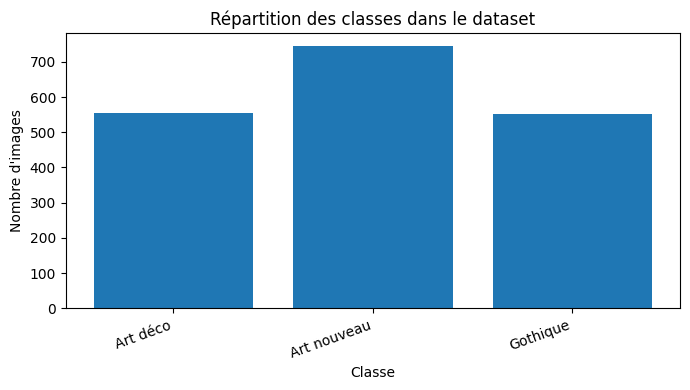

In [62]:
plot_df = dataset_df[dataset_df['Classe'] != 'Total']

plt.figure(figsize=(7, 4))
plt.bar(plot_df['Classe'], plot_df["Nombre d'images"])
plt.title('Répartition des classes dans le dataset')
plt.xlabel('Classe')
plt.ylabel("Nombre d'images")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(GRAPHS_DIR / '01_repartition_classes.png', dpi=160)
plt.show()

## 3. Résumé des modèles entraînés

Les quatre modèles ont été entraînés sur le même dataset préparé.  
La séparation utilisée est :

- **1482 images** pour l'entraînement ;
- **370 images** pour le test.

L'accuracy mesure la proportion de bonnes prédictions. Par exemple, une accuracy de `0.56` signifie que le modèle classe correctement environ 56 % des images testées.

In [63]:
rows = []
for m in models:
    rows.append({
        'Identifiant': m['id'],
        'Algorithme': m['algorithm'],
        'Train accuracy': m['train_accuracy'],
        'Test accuracy': m['test_accuracy'],
        'Écart train-test': m['train_accuracy'] - m['test_accuracy'],
        'Temps entraînement (s)': m['duration_seconds'],
        'Taille modèle (Ko)': m['model_size_bytes'] / 1024,
        'Rechargement validé': m['reload_validation'],
    })

summary_df = pd.DataFrame(rows)
summary_df = summary_df.sort_values('Test accuracy', ascending=False).reset_index(drop=True)
summary_df.to_csv(RESULTS_DIR / 'resume_modeles.csv', index=False)
summary_df

,Identifiant,Algorithme,Train accuracy,Test accuracy,Écart train-test,Temps entraînement (s),Taille modèle (Ko),Rechargement validé
0,mlp_v2,MLP,0.635628,0.567568,0.068060,59.602937,1982.932617,True
1,perceptron_v1,Perceptron,0.670715,0.521622,0.149094,5.371552,62.749023,True
2,rbf_v2,RBF,0.517544,0.518919,-0.001375,82.327997,5666.721680,True
3,svm_v1,SVM,0.674089,0.508108,0.165981,6.275721,63.184570,True


## 4. Résultats numériques des cas de test

Les premiers tests sont faits sur des jeux de données artificiels. Ils permettent de vérifier les modèles dans des situations simples et contrôlées.

Les cas utilisés sont :

- **linéaire simple** : deux groupes facilement séparables par une droite ;
- **linéaire multiple** : même idée, avec plus d’exemples ;
- **XOR** : problème non linéaire classique ;
- **Cross** : problème non linéaire avec une forme en croix ;
- **multi-classe linéaire** : plusieurs classes séparables ;
- **multi-classe non linéaire** : plusieurs classes plus difficiles à séparer.

La librairie est principalement pensée pour de la classification binaire. Pour les cas avec plusieurs classes, le programme utilise une stratégie **un-contre-tous** : un modèle est entraîné pour chaque classe, puis la classe avec le meilleur score est choisie.

In [64]:
def read_metrics(path):
    rows = []
    with open(path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            row["accuracy"] = float(row["accuracy"])
            rows.append(row)
    return rows

metrics = read_metrics(RESULTS_DIR / "metrics_cases.csv")
lines = ["| Cas | Modèle | Accuracy |", "|---|---:|---:|"]
for r in metrics:
    lines.append(f"| {r['case']} | {r['model']} | {r['accuracy']:.3f} |")
display(Markdown("\n".join(lines)))

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\sgeno\\Desktop\\github\\Projet-Annuel-3e-ann-e\\notebook_modeles_entraines_batiments_clean\\results\\metrics_cases.csv'

### Lecture du tableau

Les résultats confirment le comportement attendu :

- sur les cas linéaires, les modèles linéaires peuvent obtenir de bons résultats ;
- sur XOR et Cross, les modèles linéaires ont plus de difficultés ;
- le MLP et le RBF sont plus adaptés aux problèmes non linéaires, car ils peuvent représenter des séparations plus complexes.

Ce tableau sert donc à vérifier que les modèles ne donnent pas seulement un score, mais un score cohérent avec la forme du problème.

## 5. Comparaison globale des modèles

Le graphique suivant compare l’accuracy des modèles sur les différents cas de test.

L’**accuracy** correspond à la proportion de points correctement classés. Une accuracy de `1.0` signifie que tous les points sont correctement prédits. Une accuracy de `0.5` sur un problème à deux classes signifie que le modèle ne fait pas mieux qu’un choix très limité.

Ce graphique permet de voir rapidement quels modèles fonctionnent bien selon la forme du problème.

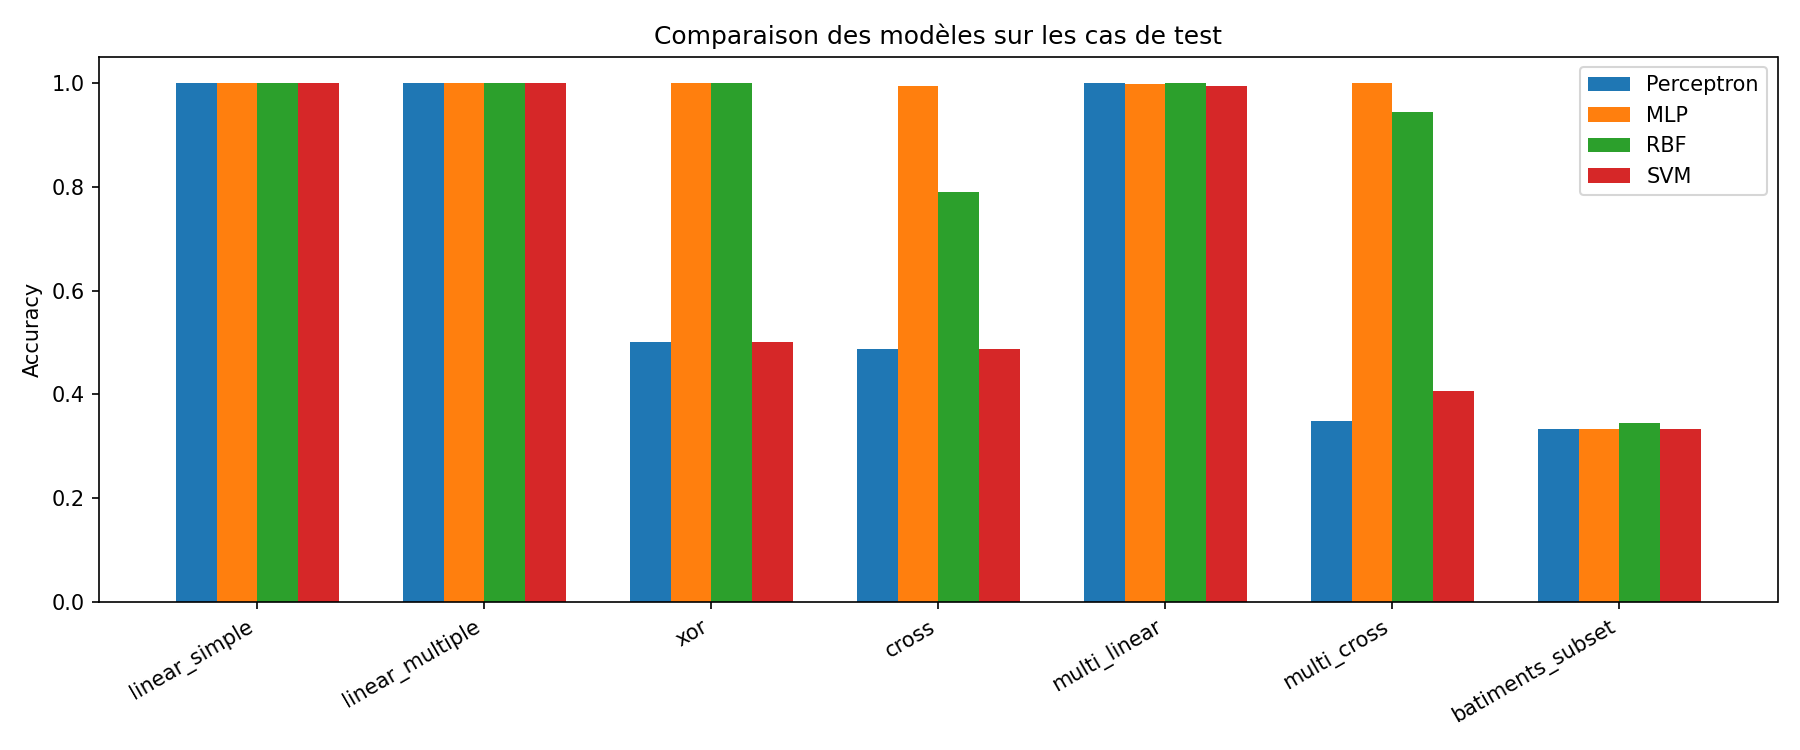

In [ ]:
display(Image(filename=str(GRAPHS_DIR / "accuracy_cas_tests.png")))


## 6. Cas de test visuels inspirés du notebook de cours

Avant d'analyser les modèles entraînés sur les bâtiments, on reprend les cas de test géométriques du notebook de cours.

Ces cas ne remplacent pas le dataset final. Ils servent à comprendre le comportement attendu des familles de modèles :

- un cas **linéaire** peut être séparé par une droite ;
- le cas **XOR** ne peut pas être séparé par une seule droite ;
- le cas **Cross** crée une forme non linéaire ;
- les cas **multi-classes** montrent pourquoi l'application utilise une stratégie un-contre-tous.

Le but est d'avoir les mêmes repères visuels que dans le notebook du professeur : points, classes et interprétation simple.


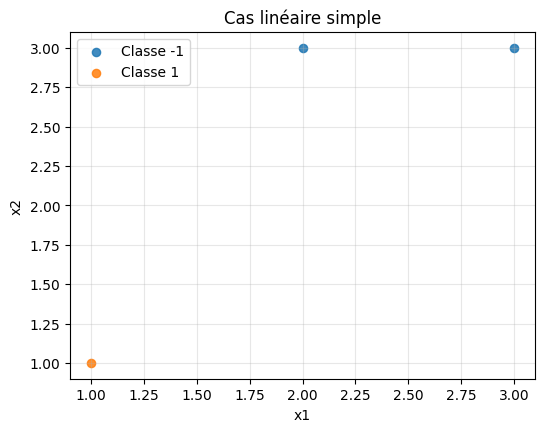

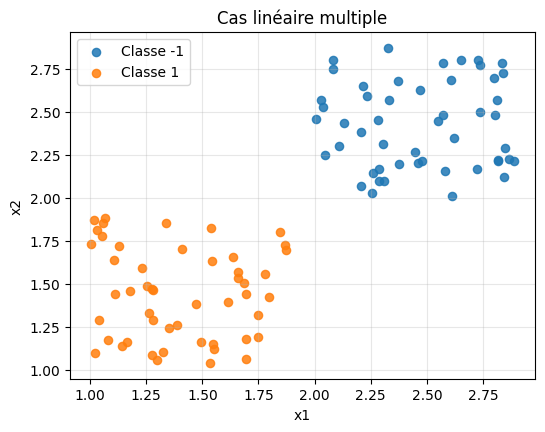

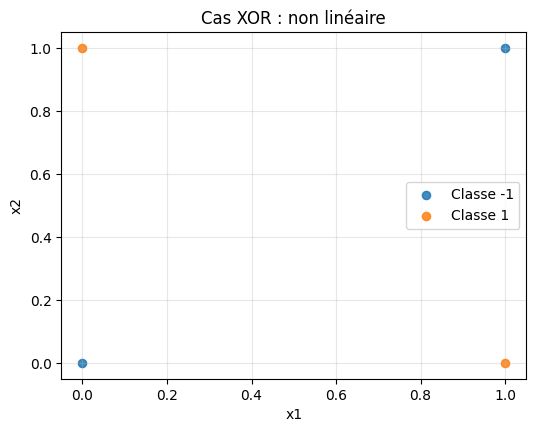

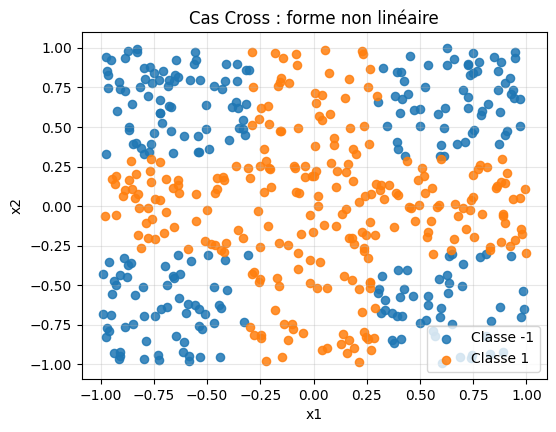

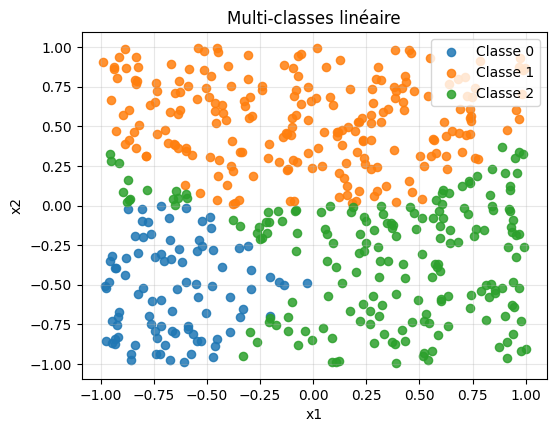

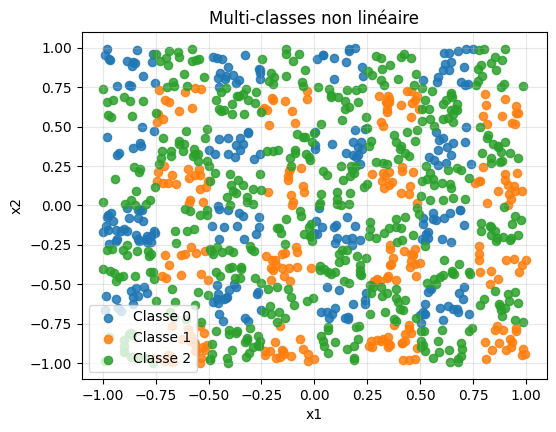

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def scatter_2d(X, y, title, labels=None):
    plt.figure(figsize=(6, 4.5))
    unique_labels = sorted(np.unique(y))
    for label in unique_labels:
        part = X[y == label]
        name = labels.get(label, f'Classe {label}') if labels else f'Classe {label}'
        plt.scatter(part[:, 0], part[:, 1], label=name, s=35, alpha=0.85)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Cas 1 : trois points linéairement séparables.
X_linear_simple = np.array([[1, 1], [2, 3], [3, 3]], dtype=float)
y_linear_simple = np.array([1, -1, -1])
scatter_2d(X_linear_simple, y_linear_simple, 'Cas linéaire simple')

# Cas 2 : deux groupes linéairement séparables.
X_linear_multiple = np.concatenate([
    np.random.random((50, 2)) * 0.9 + np.array([1, 1]),
    np.random.random((50, 2)) * 0.9 + np.array([2, 2])
])
y_linear_multiple = np.concatenate([np.ones(50), -np.ones(50)]).astype(int)
scatter_2d(X_linear_multiple, y_linear_multiple, 'Cas linéaire multiple')

# Cas 3 : XOR.
X_xor = np.array([[1, 0], [0, 1], [0, 0], [1, 1]], dtype=float)
y_xor = np.array([1, 1, -1, -1])
scatter_2d(X_xor, y_xor, 'Cas XOR : non linéaire')

# Cas 4 : Cross.
X_cross = np.random.random((500, 2)) * 2.0 - 1.0
y_cross = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X_cross])
scatter_2d(X_cross, y_cross, 'Cas Cross : forme non linéaire')

# Cas 5 : trois classes linéaires.
X_multi_linear = np.random.random((500, 2)) * 2.0 - 1.0
y_multi_linear = []
for p in X_multi_linear:
    if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0:
        y_multi_linear.append(0)
    elif -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0:
        y_multi_linear.append(1)
    else:
        y_multi_linear.append(2)
y_multi_linear = np.array(y_multi_linear)
scatter_2d(X_multi_linear, y_multi_linear, 'Multi-classes linéaire')

# Cas 6 : trois classes non linéaires.
X_multi_cross = np.random.random((1000, 2)) * 2.0 - 1.0
y_multi_cross = []
for p in X_multi_cross:
    if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25:
        y_multi_cross.append(0)
    elif abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25:
        y_multi_cross.append(1)
    else:
        y_multi_cross.append(2)
y_multi_cross = np.array(y_multi_cross)
scatter_2d(X_multi_cross, y_multi_cross, 'Multi-classes non linéaire')



### Lecture des cas de test

Les cas linéaires sont les plus simples. Une droite peut séparer les classes, donc un perceptron ou un SVM linéaire peut fonctionner.

Le XOR et le Cross sont différents : une seule droite ne peut pas séparer correctement les points. Ces cas servent à montrer l'intérêt des modèles non linéaires, comme le MLP ou le RBF.

Les cas multi-classes rappellent aussi un point important de notre application : les modèles de la librairie sont binaires à la base. Pour traiter trois classes, on entraîne donc un modèle par classe avec une logique **un-contre-tous**.


## 7. Exemples de prédictions

Les graphes suivants comparent les prédictions de certains modèles sur des cas non linéaires.

Les points bien classés et les erreurs sont visibles directement sur les figures. Cela rend la différence entre modèles plus facile à comprendre qu’un tableau seul.

Par exemple, le perceptron est un modèle linéaire. Il peut donc échouer sur XOR ou Cross, car ces problèmes ne peuvent pas être séparés correctement par une seule droite. Le MLP et le RBF peuvent créer des séparations plus souples, donc ils réussissent mieux sur ces cas.

prediction_xor_perceptron.png


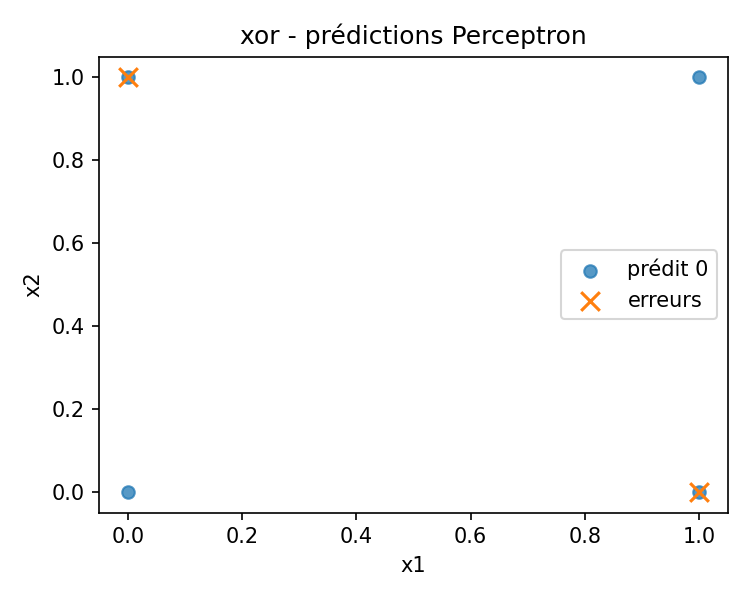

prediction_xor_mlp.png


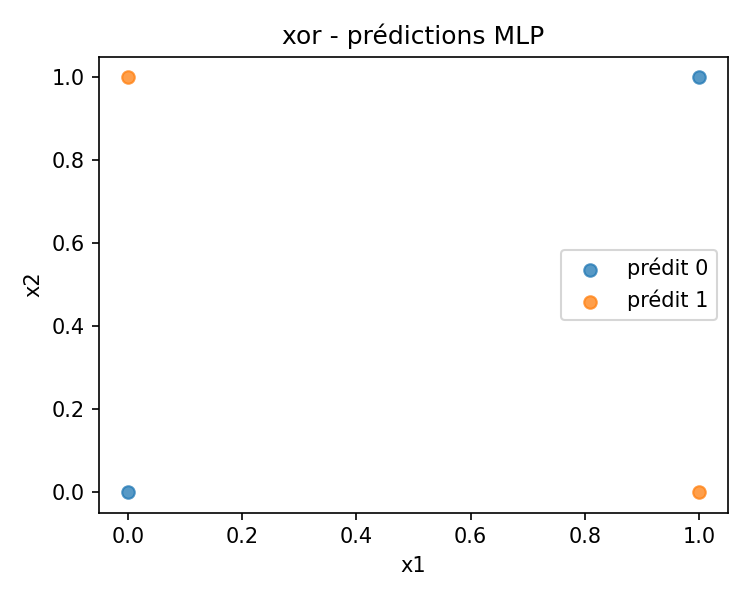

prediction_cross_perceptron.png


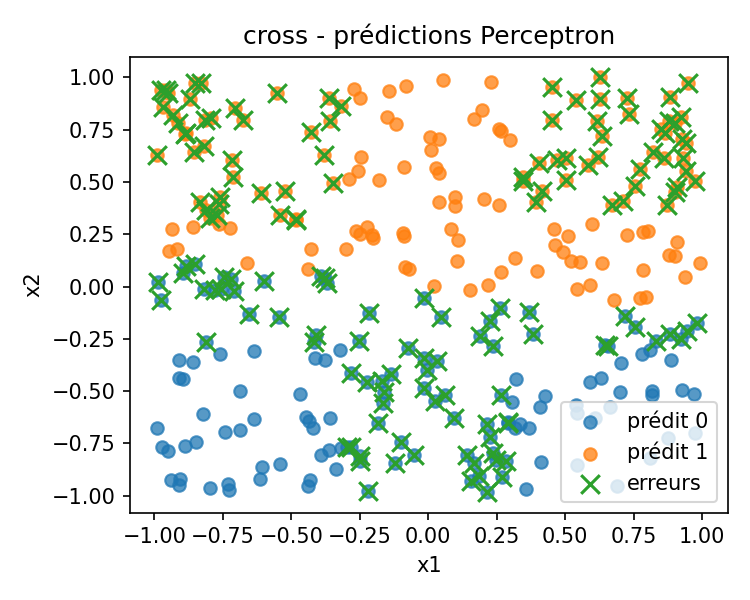

prediction_cross_mlp.png


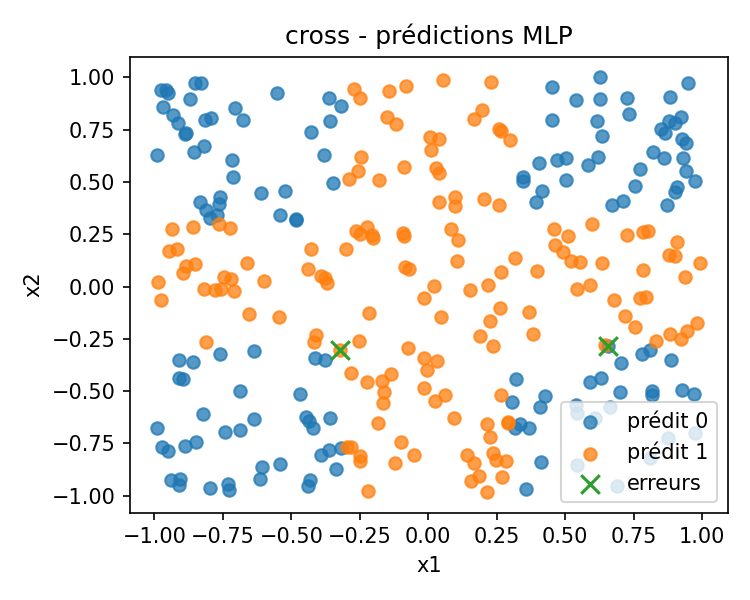

prediction_multi_cross_svm.png


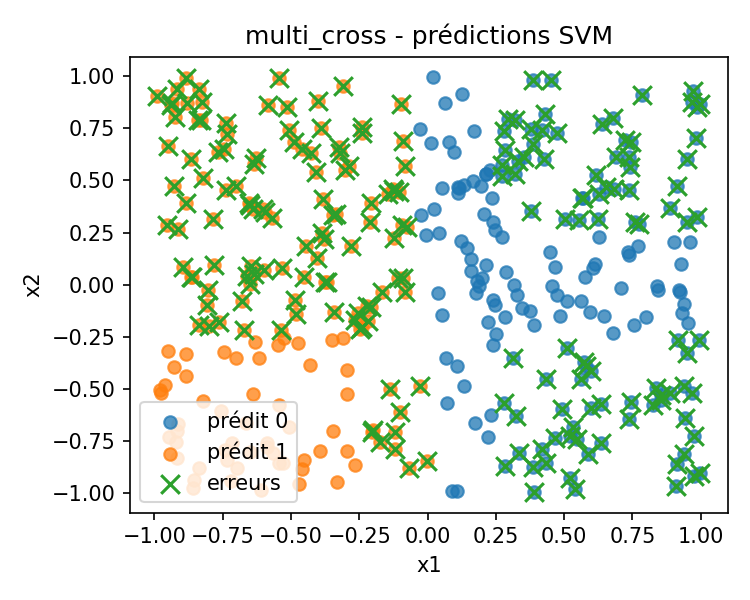

prediction_multi_cross_rbf.png


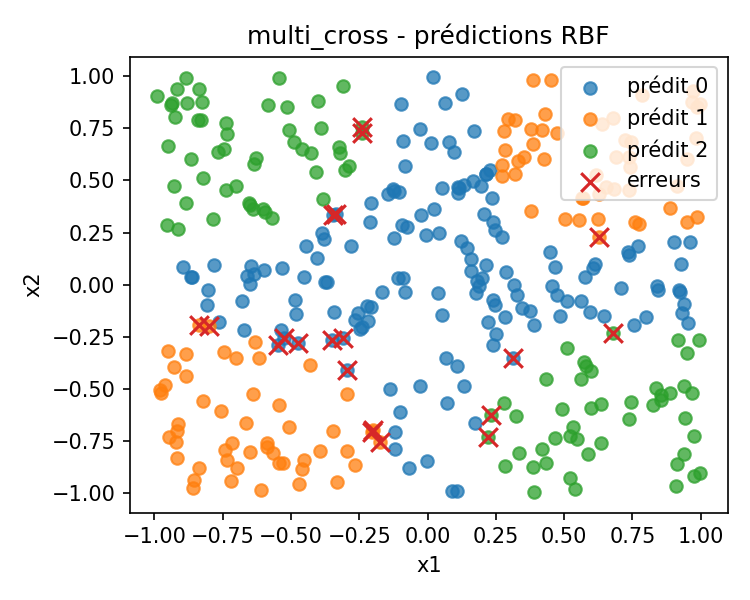

In [ ]:
for name in ["prediction_xor_perceptron.png", "prediction_xor_mlp.png", "prediction_cross_perceptron.png", "prediction_cross_mlp.png", "prediction_multi_cross_svm.png", "prediction_multi_cross_rbf.png"]:
    print(name)
    display(Image(filename=str(GRAPHS_DIR / name)))

## 8. Courbes d’apprentissage

Les courbes d’apprentissage montrent l’évolution du modèle pendant l’entraînement.

Selon le modèle, la courbe représente une erreur ou une perte. L’idée générale reste la même :

- si la courbe descend, le modèle apprend progressivement ;
- si elle reste bloquée, le modèle n’arrive pas à améliorer sa séparation ;
- si elle descend rapidement puis se stabilise, le modèle a probablement trouvé une solution correcte.

La librairie fournit des historiques pour le perceptron, le MLP et le RBF. Le notebook trace donc ces courbes uniquement pour ces modèles. Aucune courbe artificielle n’est ajoutée pour le SVM.

history_xor_perceptron.png


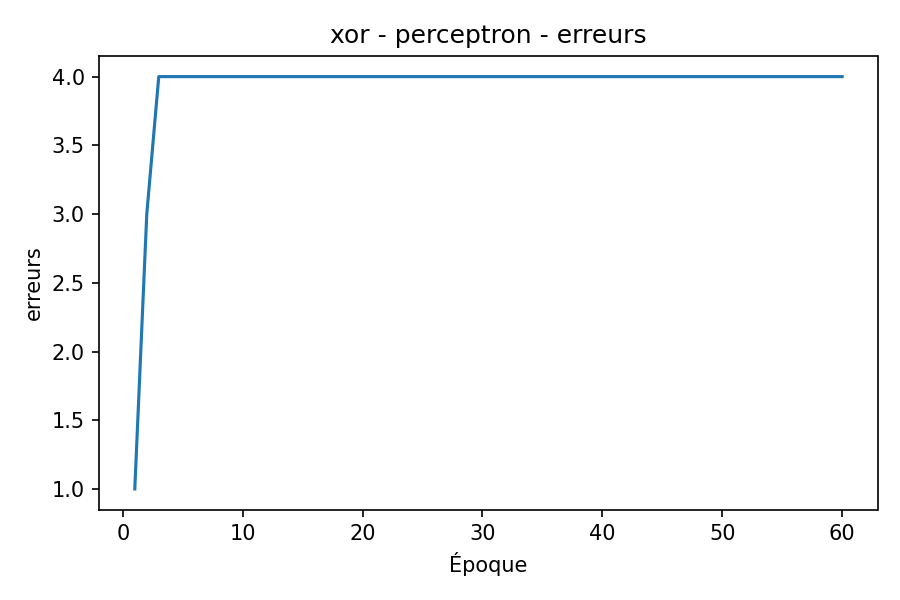

history_xor_mlp.png


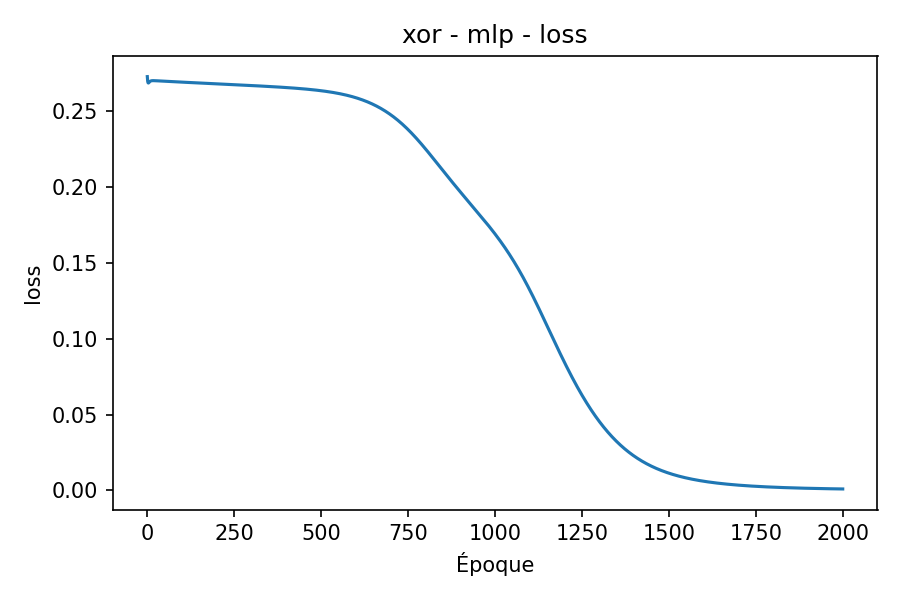

history_xor_rbf.png


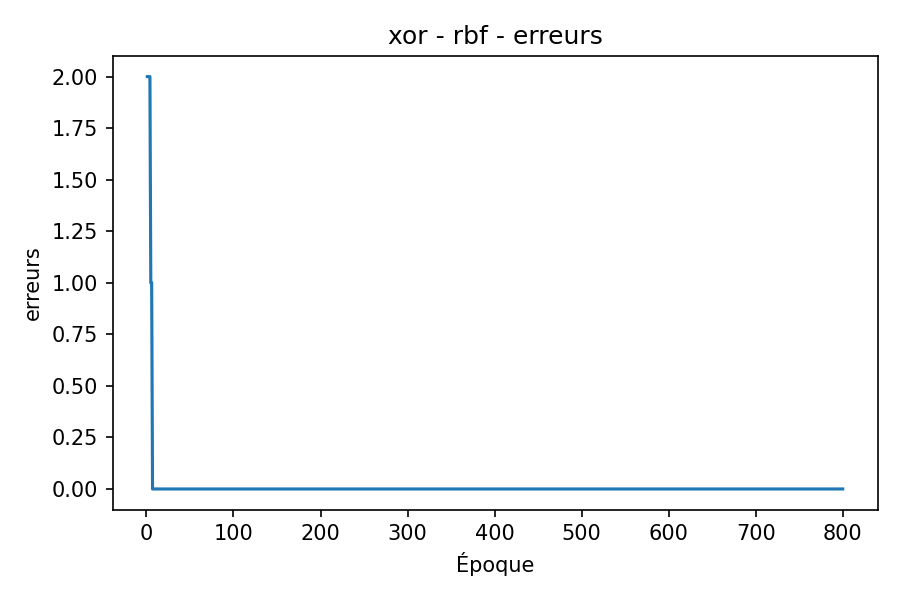

history_cross_mlp.png


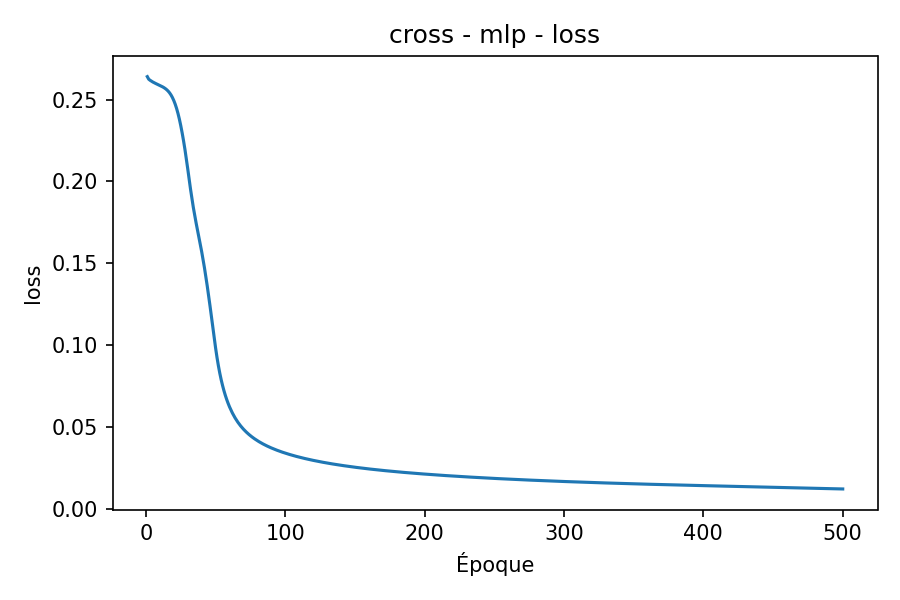

In [ ]:
for name in ["history_xor_perceptron.png", "history_xor_mlp.png", "history_xor_rbf.png", "history_cross_mlp.png"]:
    print(name)
    display(Image(filename=str(GRAPHS_DIR / name)))

## 9. Application au dataset final de bâtiments

Le dataset final contient des images de bâtiments rangées par classe. Pour pouvoir les utiliser avec la librairie, les images sont converties en données numériques.

La préparation suit le principe suivant :

1. l’image est convertie en niveaux de gris ;
2. elle est redimensionnée ;
3. les pixels sont normalisés entre `0` et `1` ;
4. l’image est transformée en vecteur de valeurs ;
5. le label de la classe est ajouté à la fin de la ligne CSV.

Pour garder le notebook rapide et léger, un sous-échantillon équilibré du dataset final est utilisé. Les images sont réduites en `16 × 16`, ce qui donne `256` valeurs par image.

Ce test montre surtout que la librairie peut être appliquée au dataset réel du projet. Les scores peuvent rester limités, car les images sont très réduites et les modèles utilisés sont volontairement simples.

### Lecture des résultats sur les bâtiments

Le dataset de bâtiments est plus difficile que les cas artificiels. Les images peuvent varier selon le cadrage, la lumière, la distance, l’angle de vue et les éléments présents autour du bâtiment.

En plus, les images utilisées ici sont fortement réduites. Une image en `16 × 16` garde seulement une information visuelle très simplifiée. Les résultats doivent donc être interprétés comme une première démonstration de fonctionnement, pas comme une performance finale maximale.

L’intérêt principal est de montrer que la même librairie peut passer des cas de test simples au dataset réel du projet.


## 10. Présentation détaillée des modèles utilisés

Cette section présente chaque modèle comme il est réellement utilisé dans l'application finale.

Le point commun le plus important est la stratégie **un-contre-tous**. Les classes du dataset sont :

```text
0 = Art déco
1 = Art nouveau
2 = Gothique
```

Pour un problème à trois classes, l'application n'entraîne pas un seul modèle multi-classe direct. Elle entraîne trois modèles binaires :

```text
modèle 0 : Art déco contre le reste
modèle 1 : Art nouveau contre le reste
modèle 2 : Gothique contre le reste
```

Au moment de prédire, les trois modèles donnent chacun un score. La classe retenue est celle qui obtient le score le plus élevé.



### 11.1 Perceptron de Rosenblatt

Le perceptron est le modèle linéaire de référence. Il sert de baseline : si un modèle plus complexe ne fait pas mieux que lui, c'est suspect.

Chaque image est transformée en un vecteur de **1024 valeurs** :

```text
32 × 32 pixels = 1024 caractéristiques
```

Pour une classe donnée, le perceptron calcule un score :

```text
score = somme(pixel × poids) + biais
```

Pendant l'entraînement, les labels sont signés :

```text
+1 = l'image appartient à la classe étudiée
-1 = l'image appartient à une autre classe
```

Si la prédiction est fausse, les poids sont corrigés dans le sens de l'exemple courant. C'est la règle de Rosenblatt.

Dans notre application :

```text
nombre de perceptrons binaires = 3
nombre de poids par perceptron = 1024
nombre total de poids = 3 × 1024
époques = 12
learning rate = 0.01
score utilisé = marge linéaire
```

Le perceptron est rapide et simple, mais il ne peut apprendre que des séparations linéaires. Sur les images de bâtiments, il ne reconnaît pas vraiment des formes architecturales : il apprend surtout des régularités statistiques dans les pixels.



### 11.2 Perceptron multicouche / MLP

Le MLP est un réseau de neurones avec une couche cachée. Il peut apprendre des relations non linéaires, donc il est plus flexible qu'un perceptron simple.

Dans notre application, le MLP de la librairie reste un modèle **binaire**. Pour les trois classes de bâtiments, il est donc utilisé en **un-contre-tous** :

```text
1 MLP pour Art déco contre le reste
1 MLP pour Art nouveau contre le reste
1 MLP pour Gothique contre le reste
```

Chaque MLP binaire possède :

```text
1024 entrées
32 neurones cachés
1 sortie sigmoïde
```

La sortie sigmoïde donne une valeur entre 0 et 1. Elle est interprétée comme une probabilité approximative pour la classe étudiée.

Important : ce n'est pas un MLP multi-classe avec softmax global. Les trois sorties viennent de trois MLP séparés. Elles sont comparées ensuite, et la classe avec la plus grande valeur est choisie.

Paramètres utilisés :

```text
nombre de MLP binaires = 3
neurones cachés = 32
époques = 12
learning rate = 0.02
score utilisé = meilleure probabilité un-contre-tous
```

Le MLP est le meilleur modèle obtenu ici. Il est moins rapide que le perceptron et le SVM, mais il capte mieux les relations non linéaires entre pixels.



### 11.3 Radial Basis Function Network / RBF

Le RBF est un modèle basé sur des **centres**. Un centre est un point de référence dans l'espace des données. Pour une image donnée, le modèle calcule sa distance à chaque centre, puis transforme cette distance avec une fonction gaussienne.

Un RBF a donc bien des centres. La question importante est : **comment ces centres sont choisis ?**

Il existe plusieurs possibilités :

```text
RBF naïf complet : un centre par exemple d'entraînement
RBF avec K-means : K centres appris par clustering
RBF simplifié : quelques centres pris directement dans les exemples
```

Dans notre application, le RBF n'utilise pas K-means et n'utilise pas l'algorithme de Lloyd. Il ne s'agit pas non plus d'un RBF naïf complet avec un centre par exemple d'entraînement.

Le code choisit les centres avec la logique suivante :

```text
centre 0 = ligne 0 du train
centre 1 = ligne 1 du train
...
centre 15 = ligne 15 du train
```

Autrement dit : les centres sont simplement les premières lignes de l'ensemble d'entraînement pour chaque modèle binaire. Ils ne sont pas optimisés.

Paramètres utilisés :

```text
nombre de RBF binaires = 3
centres par RBF binaire = 16
centres au total = 3 × 16 = 48
sigma = 1
époques = 8
learning rate = 0.05
score utilisé = meilleure probabilité un-contre-tous
```

Cette implémentation est donc mieux décrite comme :

```text
RBF simplifié à centres fixes sous-échantillonnés
```

Elle est différente d'un RBF naïf complet. Avec 1482 images d'entraînement, un RBF naïf complet aurait environ 1482 centres par modèle binaire. Ici, on n'en utilise que 16.

Cela explique probablement le mauvais comportement observé : le RBF prédit presque toujours la classe Gothique. La matrice de confusion montre que toutes les images de test sont envoyées vers cette classe.

Ce comportement ressemble davantage à un problème de réglage ou de conception qu'à une simple limite normale du RBF. Les causes probables sont :

```text
- trop peu de centres pour représenter 1482 images d'entraînement ;
- centres choisis trop naïvement, sans K-means ;
- sigma = 1 peut être mal adapté à des vecteurs de 1024 dimensions ;
- activations gaussiennes souvent trop faibles ;
- le biais peut dominer la sortie ;
- le modèle finit par privilégier une seule classe.
```

Pour améliorer ce RBF, il faudrait tester au moins une des solutions suivantes :

```text
- utiliser plus de centres ;
- choisir les centres aléatoirement et de façon équilibrée par classe ;
- utiliser K-means / Lloyd pour calculer des centres représentatifs ;
- ajuster sigma à partir des distances moyennes entre centres ;
- normaliser ou réduire la dimension des données avant le RBF.
```



### 11.4 Support Vector Machine / SVM

Le SVM utilisé est un **SVM linéaire**. Il ne possède pas de kernel RBF, polynomial ou autre. Il cherche donc une séparation linéaire entre une classe et les autres.

Comme les autres modèles de la librairie, il est utilisé en **un-contre-tous** :

```text
1 SVM pour Art déco contre le reste
1 SVM pour Art nouveau contre le reste
1 SVM pour Gothique contre le reste
```

Les labels sont signés :

```text
+1 = classe étudiée
-1 = autre classe
```

Le SVM ne cherche pas seulement à classer correctement. Il cherche aussi à garder une marge suffisante entre les points et la frontière. La condition utilisée est liée à :

```text
label × score >= 1
```

Si la marge est suffisante, le modèle applique surtout la régularisation. Si la marge est insuffisante, il corrige les poids dans le sens de l'exemple.

Paramètres utilisés :

```text
nombre de SVM binaires = 3
kernel = aucun, SVM linéaire
SMO = non utilisé
époques = 12
learning rate = 0.005
lambda = 0.001
score utilisé = marge linéaire
```

Le SVM obtient des résultats proches du perceptron. C'est logique : les deux modèles restent linéaires. Le SVM est plus structuré grâce à la notion de marge, mais il ne peut pas inventer une séparation non linéaire sans kernel.



### 11.5 Points techniques importants à retenir

Le tableau suivant résume les choix d'implémentation. Ce sont les points importants à connaître pour répondre aux questions techniques.

| Modèle | Type exact | Multi-classe | Centres / structure | Paramètres principaux | Point de vigilance |
|---|---|---|---|---|---|
| Perceptron | linéaire | 3 modèles un-contre-tous | 1024 poids + biais par classe | 12 époques, lr = 0.01 | ne peut apprendre que du linéaire |
| MLP | non linéaire | 3 MLP binaires un-contre-tous | 1024 entrées, 32 neurones cachés, 1 sortie | 12 époques, lr = 0.02 | pas un softmax global multi-classe |
| RBF | non linéaire simplifié | 3 RBF binaires un-contre-tous | 16 centres fixes par modèle, 48 centres au total | 8 époques, lr = 0.05, sigma = 1 | pas K-means, pas Lloyd, pas un centre par exemple |
| SVM | linéaire | 3 modèles un-contre-tous | 1024 poids + biais par classe | 12 époques, lr = 0.005, lambda = 0.001 | pas de kernel, pas de SMO complet |

Autre point important : la librairie utilise **Eigen** pour les calculs de matrices et de vecteurs. Ce n'est pas une librairie de machine learning : les algorithmes sont codés dans la librairie du projet.


## 12. Comparaison des accuracies

Le graphique suivant compare l'accuracy sur l'ensemble d'entraînement et sur l'ensemble de test.

L'accuracy de test est la plus importante, car elle mesure la performance sur des images que le modèle n'a pas vues pendant l'entraînement.

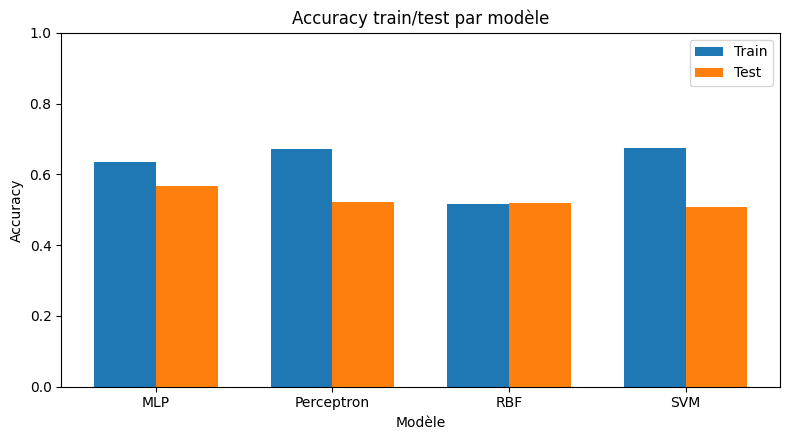

In [ ]:
ordered = summary_df.sort_values('Test accuracy', ascending=False)
x = np.arange(len(ordered))
width = 0.35

plt.figure(figsize=(8, 4.5))
plt.bar(x - width/2, ordered['Train accuracy'], width, label='Train')
plt.bar(x + width/2, ordered['Test accuracy'], width, label='Test')
plt.title('Accuracy train/test par modèle')
plt.xlabel('Modèle')
plt.ylabel('Accuracy')
plt.xticks(x, ordered['Algorithme'])
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(GRAPHS_DIR / '02_accuracy_train_test.png', dpi=160)
plt.show()

## 13. Interprétation générale

Le **MLP** obtient la meilleure accuracy de test. Cela est cohérent avec son fonctionnement : il ajoute une couche cachée qui permet d'apprendre des relations plus complexes qu'une simple séparation linéaire.

Le **Perceptron** et le **SVM** restent assez proches. Ce sont des modèles linéaires : ils peuvent fonctionner comme baseline, mais ils ont du mal si les classes ne sont pas séparables simplement dans l'espace des pixels.

Le **RBF** obtient ici un mauvais résultat. Sa matrice de confusion montre qu'il prédit presque toujours la même classe. Cela indique que le réglage choisi n'est pas adapté à ce dataset de 1024 caractéristiques.

## 14. Matrices de confusion

Une matrice de confusion indique où le modèle se trompe.

- Les lignes représentent les vraies classes ;
- Les colonnes représentent les classes prédites ;
- La diagonale correspond aux bonnes prédictions.

Plus les valeurs de la diagonale sont grandes, meilleur est le modèle.

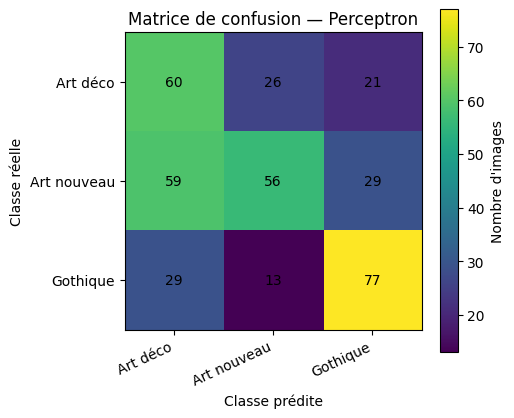

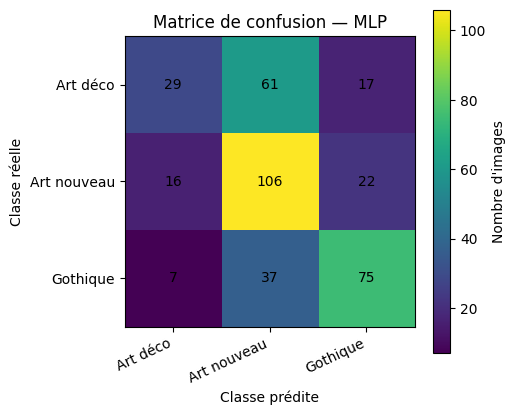

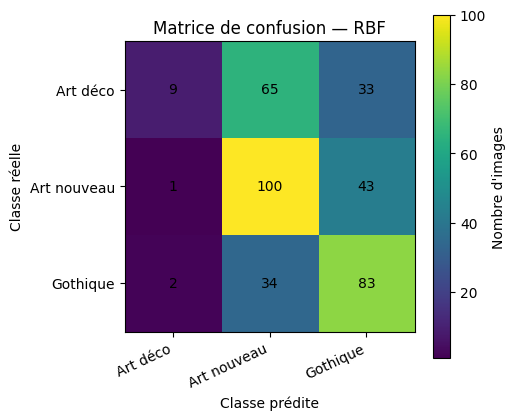

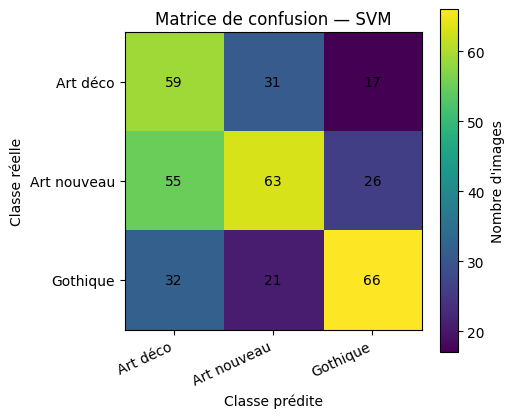

In [ ]:
def plot_confusion_matrix(matrix, title, filename):
    matrix = np.array(matrix)
    labels = [classes[i] for i in sorted(classes)]

    plt.figure(figsize=(5.2, 4.5))
    plt.imshow(matrix)
    plt.title(title)
    plt.xlabel('Classe prédite')
    plt.ylabel('Classe réelle')
    plt.xticks(range(len(labels)), labels, rotation=25, ha='right')
    plt.yticks(range(len(labels)), labels)
    plt.colorbar(label='Nombre d\'images')

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            plt.text(j, i, str(matrix[i, j]), ha='center', va='center')

    plt.tight_layout()
    plt.savefig(GRAPHS_DIR / filename, dpi=160)
    plt.show()

for m in models:
    plot_confusion_matrix(
        m['confusion_matrix'],
        f"Matrice de confusion — {m['algorithm']}",
        f"03_confusion_{m['id']}.png"
    )

## 15. Lecture des matrices de confusion

Les matrices montrent plusieurs points importants :

- **Art nouveau** est souvent la classe la mieux reconnue par le MLP, mais elle attire aussi beaucoup d'erreurs venant des autres classes.
- **Art déco** est souvent confondu avec Art nouveau. C'est logique, car ces deux styles peuvent partager des formes géométriques, des façades urbaines et des éléments décoratifs proches.
- **Gothique** est mieux reconnu par certains modèles, probablement grâce à des formes plus marquées comme les arcs, verticalités et ouvertures.
- Le **RBF** prédit presque tout en Gothique dans cette configuration, ce qui montre un échec de réglage plutôt qu'une réussite du modèle.

## 16. Temps d'entraînement et taille des modèles

Un modèle n'est pas évalué uniquement avec son accuracy. Il faut aussi regarder son coût :

- temps nécessaire pour l'entraîner ;
- taille du fichier sauvegardé ;
- facilité à l'utiliser dans l'application.

Le MLP obtient la meilleure accuracy, mais il est aussi beaucoup plus lourd et plus lent que le perceptron ou le SVM.

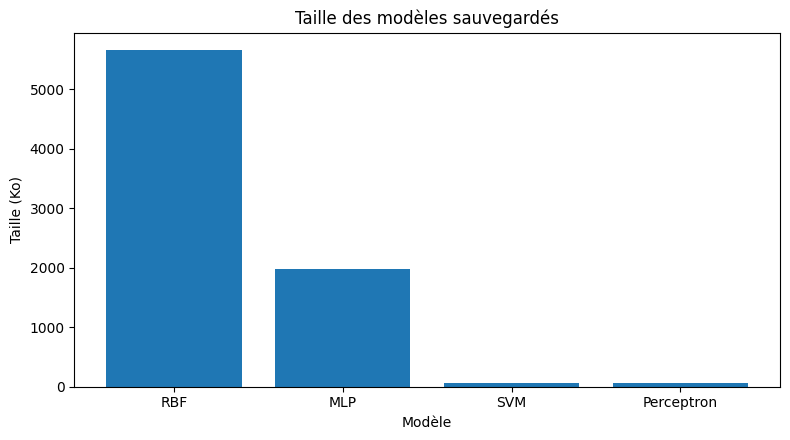

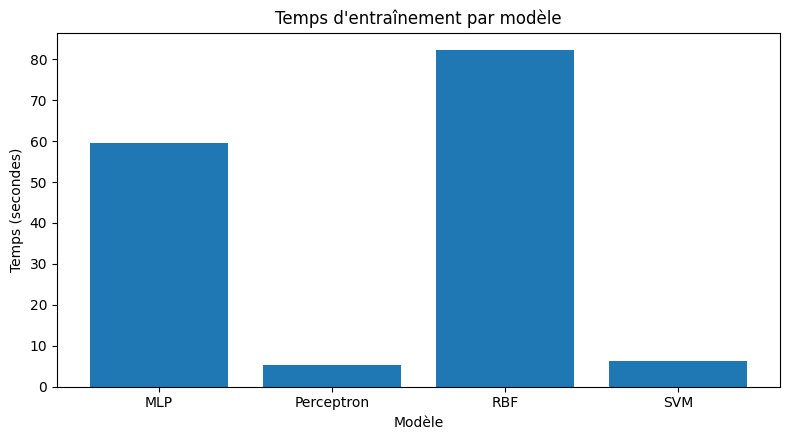

In [ ]:
size_df = summary_df.sort_values('Taille modèle (Ko)', ascending=False)

plt.figure(figsize=(8, 4.5))
plt.bar(size_df['Algorithme'], size_df['Taille modèle (Ko)'])
plt.title('Taille des modèles sauvegardés')
plt.xlabel('Modèle')
plt.ylabel('Taille (Ko)')
plt.tight_layout()
plt.savefig(GRAPHS_DIR / '04_taille_modeles.png', dpi=160)
plt.show()

plt.figure(figsize=(8, 4.5))
plt.bar(summary_df['Algorithme'], summary_df['Temps entraînement (s)'])
plt.title("Temps d'entraînement par modèle")
plt.xlabel('Modèle')
plt.ylabel('Temps (secondes)')
plt.tight_layout()
plt.savefig(GRAPHS_DIR / '05_temps_entrainement.png', dpi=160)
plt.show()

## 17. Analyse du tuning

Des essais de paramètres ont été faits pour certains modèles.  
Le but n'est pas de tester toutes les combinaisons possibles, mais de vérifier si quelques réglages simples améliorent les résultats.

Le tuning utilise une partie de validation séparée. Le test final n'est donc pas utilisé pour choisir les paramètres, ce qui évite de favoriser artificiellement un modèle.

In [ ]:
tuning_dir = REPORTS_DIR / 'tuning'
with open(tuning_dir / 'tuning_summary.json', 'r', encoding='utf-8') as f:
    tuning_summary = json.load(f)

candidate_files = {
    'Perceptron': tuning_dir / 'perceptron_candidates.json',
    'MLP': tuning_dir / 'mlp_candidates.json',
    'SVM': tuning_dir / 'svm_candidates.json',
}

tuning_rows = []
for algorithm, path in candidate_files.items():
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    for candidate in data['candidates']:
        tuning_rows.append({
            'Algorithme': algorithm,
            'Candidat': candidate['name'],
            'Epochs': candidate['epochs'],
            'Learning rate': candidate['learning_rate'],
            'Hidden size': candidate.get('hidden_size', ''),
            'Validation accuracy': candidate['validation_accuracy'],
            'Train accuracy': candidate['train_accuracy'],
            'Temps (s)': candidate['duration_seconds'],
        })

tuning_df = pd.DataFrame(tuning_rows)
tuning_df.to_csv(RESULTS_DIR / 'tuning_candidates.csv', index=False)
tuning_df

,Algorithme,Candidat,Epochs,Learning rate,Hidden size,Validation accuracy,Train accuracy,Temps (s)
0,Perceptron,v1_reference,12,0.010,16,0.516892,0.568297,3.529009
1,Perceptron,more_epochs_lower_lr,25,0.005,16,0.459459,0.544688,7.673094
2,Perceptron,more_epochs_small_lr,30,0.002,16,0.523649,0.604553,9.223608
3,Perceptron,moderate_epochs_higher_lr,20,0.020,16,0.520270,0.618044,6.792775
4,MLP,v1_reference,8,0.030,16,0.496622,0.537099,41.197219
5,MLP,more_epochs_lower_lr,15,0.020,16,0.503378,0.587690,67.931815
6,MLP,more_epochs_small_lr,20,0.010,16,0.516892,0.580944,76.523260
7,MLP,wider_hidden_layer,12,0.020,32,0.520270,0.580944,79.503717
8,SVM,v1_reference,12,0.005,16,0.527027,0.587690,7.637725
9,SVM,more_epochs_lower_lr,25,0.002,16,0.506757,0.613828,12.888019


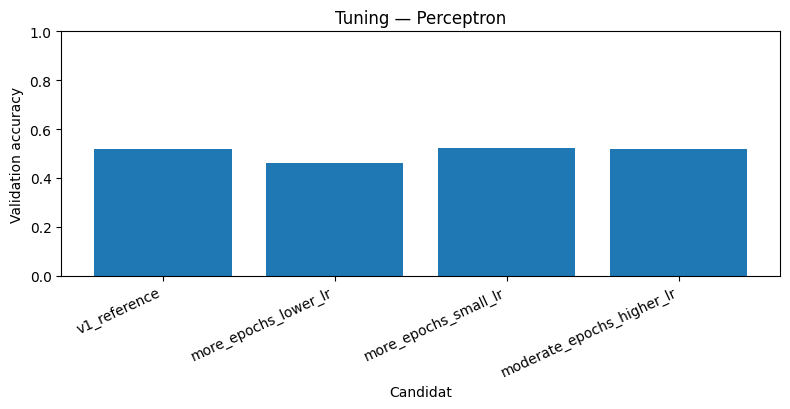

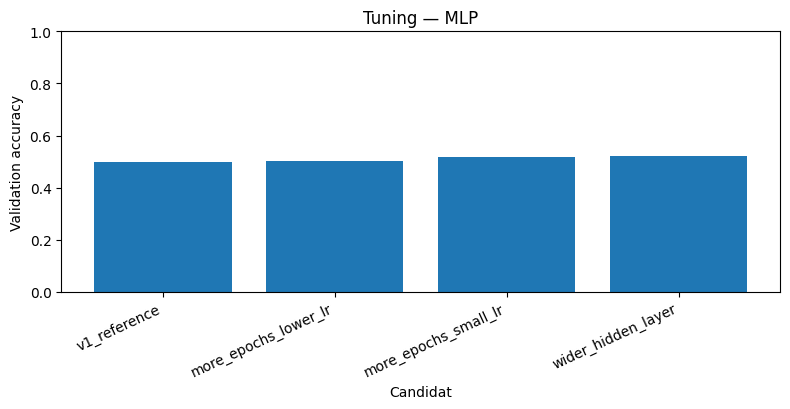

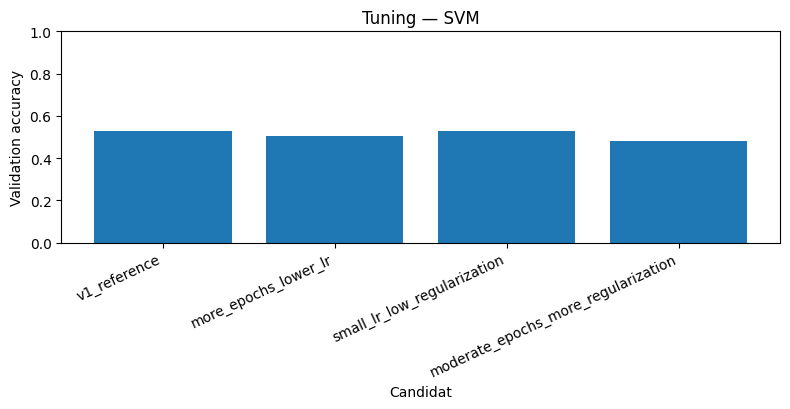

In [65]:
for algorithm in tuning_df['Algorithme'].unique():
    part = tuning_df[tuning_df['Algorithme'] == algorithm].copy()

    plt.figure(figsize=(8, 4.2))
    plt.bar(part['Candidat'], part['Validation accuracy'])
    plt.title(f'Tuning — {algorithm}')
    plt.xlabel('Candidat')
    plt.ylabel('Validation accuracy')
    plt.ylim(0, 1)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    safe_name = algorithm.lower().replace(' ', '_')
    plt.savefig(GRAPHS_DIR / f'06_tuning_{safe_name}.png', dpi=160)
    plt.show()

## 18. Résultat retenu

Le meilleur modèle retenu dans cette version est le **MLP v2**.

Il n'est pas parfait, mais il donne la meilleure accuracy de test parmi les quatre modèles. Cela montre que le problème est plus complexe qu'une simple séparation linéaire entre classes.

Le score reste limité, car les images sont réduites à 32 × 32 en niveaux de gris. Le modèle perd donc beaucoup d'informations visuelles : couleurs, détails fins, textures et contexte architectural.

In [ ]:
best_model = summary_df.iloc[0]

best_summary = pd.DataFrame([
    ['Meilleur modèle', best_model['Algorithme']],
    ['Identifiant', best_model['Identifiant']],
    ['Accuracy test', round(best_model['Test accuracy'], 4)],
    ['Accuracy train', round(best_model['Train accuracy'], 4)],
    ['Temps entraînement (s)', round(best_model['Temps entraînement (s)'], 2)],
    ['Taille modèle (Ko)', round(best_model['Taille modèle (Ko)'], 2)],
], columns=['Information', 'Valeur'])

best_summary.to_csv(RESULTS_DIR / 'meilleur_modele.csv', index=False)
best_summary

,Information,Valeur
0,Meilleur modèle,MLP
1,Identifiant,mlp_v2
2,Accuracy test,0.5676
3,Accuracy train,0.6356
4,Temps entraînement (s),59.6
5,Taille modèle (Ko),1982.93


## 19. Lien avec l'application finale

Les modèles analysés ici sont les mêmes que ceux utilisés dans l'application finale.

L'application web charge un modèle sauvegardé, transforme une image en vecteur de 1024 pixels, puis renvoie la classe prédite.

Le notebook sert donc à justifier les choix de modèles et à visualiser leurs performances. L'application sert ensuite à utiliser ces modèles sur de nouvelles images.

In [ ]:
model_files = []
for m in models:
    path = MODELS_DIR / m['file']
    model_files.append({
        'Modèle': m['algorithm'],
        'Fichier': m['file'],
        'Existe': path.exists(),
        'Taille réelle (Ko)': path.stat().st_size / 1024 if path.exists() else None,
        'Rechargement validé': m['reload_validation'],
    })

model_files_df = pd.DataFrame(model_files)
model_files_df.to_csv(RESULTS_DIR / 'fichiers_modeles.csv', index=False)
model_files_df

,Modèle,Fichier,Existe,Taille réelle (Ko),Rechargement validé
0,Perceptron,buildings_3classes_32x32_perceptron_v1.model,True,62.740234,True
1,MLP,buildings_3classes_32x32_mlp_v2.model,True,1982.917969,True
2,RBF,buildings_3classes_32x32_rbf_v2.model,True,5666.709961,True
3,SVM,buildings_3classes_32x32_svm_v1.model,True,63.175781,True


## 20. Bilan

Cette démonstration montre que :

- les quatre modèles sont bien entraînés et sauvegardés ;
- les modèles peuvent être rechargés correctement ;
- le MLP donne le meilleur résultat sur le test ;
- les modèles linéaires sont rapides mais limités ;
- le RBF nécessite un meilleur réglage pour être utile sur ce dataset ;
- les confusions entre styles sont visibles dans les matrices de confusion ;
- l'application finale peut utiliser ces modèles pour prédire de nouvelles images.

Le résultat est donc exploitable pour le rendu : le notebook explique les performances, et l'application montre l'utilisation concrète des modèles entraînés.